# Синергия узлов: обученная сеть против необученной

**Взаимодействие между узлами**: если
убрать два узла слоя одновременно, эффект на логит класса сильнее или слабее, чем сумма эффектов от каждого по
отдельности (синергия / субаддитивность, тест S из `experiment_common_task.ipynb`). Вопрос: каково распределение
синергичных и субаддитивных пар по слоям в обученной сети по сравнению с необученной.

**Как запустить.** `pip install -r requirements.txt` из корня репозитория, затем выполнить ноутбук по ячейкам.
Обученные сети переиспользуются из `cache/common`, если он есть (после запуска `experiment_common_task.ipynb`) -
если его нет, сети обучатся заново (дольше, но результат тот же: seed зафиксирован). MNIST и CIFAR-10 при первом
запуске скачиваются в `data/` автоматически`. Парный скрининг (раздел 3) - дорогая по времени операция (для CIFAR-10 - порядка
20 минут на 13 сетей), поэтому результат кэшируется **по каждой сети отдельно** (`cache/untrained_control/pairs_*.pkl`) -
уже посчитанное не пересчитывается заново ни при повторном запуске, ни после прерывания на середине.

## 1. Зачем этот эксперимент

Метод из `experiment_common_task.ipynb` (раздел 1) для каждого узла слоя проверяет: если убрать только этот узел,
значимо ли меняется логит класса? Это даёт список "критичных" узлов - но ничего не говорит о **взаимодействии** между
ними. Расширение этого метода (там же, раздел 3) добавляет второй тест: для каждой ПАРЫ узлов слоя проверяется, что
эффект от удаления обоих сразу отличается от суммы эффектов по отдельности:

- S > 0 значимо ("синергия") - узлы дополняют друг друга, эффект пары сильнее суммы;
- S < 0 значимо ("субаддитивность") - узлы дублируют друг друга, эффект пары слабее суммы;
- иначе - "аддитивность" (эффекты не зависят друг от друга).

Раздел 6.7 `experiment_common_task.ipynb` ("Контроль на необученной сети") уже проверял этот тест на сети со
случайными, необученными весами - на выборке всего из 2-3 таких сетей - и получил разнонаправленный результат: в
conv1 неаддитивных пар оказалось больше у обученной сети, в conv2 - у необученной. Если это так, сам факт "пара
значима по тесту S" не доказывает, что сеть чему-то научилась - это касается валидности метрики S в целом, а не
конкретного правила прунинга, которое на ней основано. Проблема в том, что 2-3 случайные сети - слишком маленькая
выборка, чтобы понять, устойчив ли этот эффект или это шум. Здесь тот же контроль ставится на `N_UNTRAINED` (по
умолчанию 8) независимых необученных сетях на каждый датасет, plus 5 обученных (те же 5 seeds, что и в
`experiment_common_task.ipynb`), на двух датасетах (MNIST, CIFAR-10) - чтобы увидеть, воспроизводится ли
разнонаправленный эффект по слоям и одинаково ли он выглядит на обоих датасетах.

Парный скрининг применим только к conv1 и conv2: на этапе fc1 -> fc2 логит линеен по весам fc2, поэтому S тождественно
равен нулю и синергии/субаддитивности там в принципе быть не может.

## 2. Код

Ячейки ниже повторяют метод интервенций (Algorithm 1 + расширение EXT с парным скринингом синергии) из `experiment_common_task.ipynb`, затем считают синергичные/субаддитивные пары для обученных и необученных сетей.

In [1]:
# 0. Окружение, конфигурация, данные, модель. Сеть, обучение и пороги метода совпадают с experiment_common_task.ipynb,
# чтобы обученные сети из cache/common можно было переиспользовать без переобучения.
import sys, os, gzip, struct, io, time, pickle, random, warnings, shutil
from pathlib import Path
from itertools import combinations
from typing import Optional
from dataclasses import dataclass
from urllib.request import Request, urlopen, urlretrieve
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import torch, torch.nn as nn, torch.nn.functional as F
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)   # t-тест на константном векторе (мёртвый узел) даёт nan

QUICK      = os.environ.get('NB_QUICK') == '1'
DATASETS   = os.environ['NB_DATASETS'].split(',') if os.environ.get('NB_DATASETS') else (['MNIST'] if QUICK else ['MNIST', 'CIFAR-10'])
SEEDS      = [42] if QUICK else [42, 0, 1, 2, 3]           # обученные сети - те же 5 семян, что и в experiment_common_task.ipynb
N_UNTRAINED = 3 if QUICK else 8                             # число необученных (случайно инициализированных) сетей на датасет
UNTRAINED_SEEDS = [2000 + i for i in range(N_UNTRAINED)]
ALPHA      = 0.05         # уровень значимости, как в статье
FDR_METHOD = 'fdr_by'     # Benjamini-Yekutieli: парные тесты структурно зависимы (как в experiment_common_task.ipynb)
TAU_REL    = 0.02         # порог размера эффекта, в долях std логита класса
N_CAL      = 128
TRAIN_CACHE_DIR = Path('cache/common'); TRAIN_CACHE_DIR.mkdir(parents=True, exist_ok=True)   # переиспользуем уже обученные сети
CACHE_DIR  = Path('cache/untrained_control'); CACHE_DIR.mkdir(parents=True, exist_ok=True)
USE_CACHE  = True

random.seed(42); np.random.seed(42); torch.manual_seed(42)
torch.use_deterministic_algorithms(True, warn_only=True)
device = torch.device('cpu'); torch.set_num_threads(4)
print('Device:', device, '| QUICK =', QUICK, '| датасеты:', DATASETS, '| обученных семян:', len(SEEDS), '| необученных сетей на датасет:', N_UNTRAINED)

DS = {
    'MNIST':    dict(in_ch=1, size=28, widths=(6, 10, 24),  s=4, n_train=12000, n_sel=8000, n_meta=10000, epochs=6),
    'CIFAR-10': dict(in_ch=3, size=32, widths=(16, 32, 64), s=5, n_train=40000, n_sel=5000, n_meta=5000,  epochs=10),
}

def _load_mnist():
    root = Path('data/mnist_raw'); root.mkdir(parents=True, exist_ok=True)
    base = 'https://storage.googleapis.com/cvdf-datasets/mnist/'
    files = {'tr_x': 'train-images-idx3-ubyte.gz', 'tr_y': 'train-labels-idx1-ubyte.gz', 'te_x': 't10k-images-idx3-ubyte.gz', 'te_y': 't10k-labels-idx1-ubyte.gz'}
    for f in files.values():
        if not (root / f).exists(): urlretrieve(base + f, root / f)
    def img(p):
        with gzip.open(root / p, 'rb') as f:
            _, n, r, c = struct.unpack('>IIII', f.read(16)); return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, 1, r, c).copy()
    def lab(p):
        with gzip.open(root / p, 'rb') as f:
            f.read(8); return np.frombuffer(f.read(), dtype=np.uint8).astype(np.int64).copy()
    return img(files['tr_x']), lab(files['tr_y']), img(files['te_x']), lab(files['te_y'])

def _load_cifar():
    root = Path('data/cifar10_raw'); root.mkdir(parents=True, exist_ok=True); npz = root / 'cifar10_u8.npz'
    if not npz.exists():
        from PIL import Image
        base = 'https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/'
        out = {}
        for split, name in [('train', 'train-00000-of-00001.parquet'), ('test', 'test-00000-of-00001.parquet')]:
            path = root / f'cifar10_{split}.parquet'
            if not path.exists():
                with urlopen(Request(base + name, headers={'User-Agent': 'Mozilla/5.0'}), timeout=120) as r, open(path, 'wb') as f: shutil.copyfileobj(r, f)
            df = pd.read_parquet(path)
            out[f'x_{split}'] = np.ascontiguousarray(np.stack([np.array(Image.open(io.BytesIO(d['bytes'])).convert('RGB')) for d in df['img']]).transpose(0, 3, 1, 2))
            out[f'y_{split}'] = df['label'].to_numpy(dtype=np.int64)
        np.savez(npz, **out)
    z = np.load(npz); return z['x_train'], z['y_train'], z['x_test'], z['y_test']

class Data:
    "Изображения хранятся как uint8 и нормируются по батчам."
    MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1); STD = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)
    def __init__(self, name):
        self.name, self.cfg = name, DS[name]
        xtr, ytr, xte, yte = _load_mnist() if name == 'MNIST' else _load_cifar()
        self.xtr, self.ytr, self.xte, self.yte = map(torch.from_numpy, (xtr, ytr, xte, yte))
        c = self.cfg; perm = torch.randperm(len(self.ytr), generator=torch.Generator().manual_seed(42))
        a, b, d = c['n_train'], c['n_train'] + c['n_sel'], c['n_train'] + c['n_sel'] + c['n_meta']
        self.train_idx, self.sel_idx, self.meta_idx = perm[:a], perm[a:b], perm[b:d]
    def prep(self, xu8):
        x = xu8.float().div_(255)
        return x if self.name == 'MNIST' else (x - self.MEAN) / self.STD
    def x_train(self, idx): return self.prep(self.xtr[idx])
    def y_train(self, idx): return self.ytr[idx]

class ConvNet(nn.Module):
    "conv1 -> pool -> conv2 -> pool -> fc1 -> fc2. Ширины (c1, c2, f1) параметризованы, как в предыдущих экспериментах."
    def __init__(self, in_ch, widths, s, n_out=10):
        super().__init__(); c1, c2, f1 = widths; self.s = s
        self.conv1 = nn.Conv2d(in_ch, c1, 5); self.conv2 = nn.Conv2d(c1, c2, 5)
        self.fc1 = nn.Linear(c2 * s * s, f1); self.fc2 = nn.Linear(f1, n_out)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2); x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        return self.fc2(F.relu(self.fc1(x.flatten(1))))

def new_net(data, widths=None, n_out=10, seed=None):
    # Свежая сеть со случайной инициализацией PyTorch. seed фиксирует инициализацию; без train_net сеть остаётся необученной.
    if seed is not None: torch.manual_seed(seed)
    return ConvNet(data.cfg['in_ch'], widths or data.cfg['widths'], data.cfg['s'], n_out).to(device)

def train_net(net, data, epochs, lr, seed):
    g = torch.Generator().manual_seed(seed); opt = torch.optim.Adam(net.parameters(), lr=lr); idx = data.train_idx
    for _ in range(epochs):
        net.train(); order = torch.randperm(len(idx), generator=g)
        for i in range(0, len(idx), 128):
            b = idx[order[i:i + 128]]; xb, yb = data.x_train(b), data.y_train(b)
            opt.zero_grad(); loss = F.cross_entropy(net(xb), yb); loss.backward(); opt.step()
    return net.eval()

@torch.no_grad()
def logits_on(net, xu8, data, batch=2500):
    net.eval(); return torch.cat([net(data.prep(xu8[i:i + batch])) for i in range(0, len(xu8), batch)])

def get_net(data, seed):
    # Обученная сеть: если experiment_common_task.ipynb уже обучил и сохранил сеть с этим семенем - переиспользуем
    # (общий cache/common), иначе обучаем заново.
    path = TRAIN_CACHE_DIR / f'net_{data.name}_{seed}.pt'
    if USE_CACHE and path.exists():
        net = new_net(data); net.load_state_dict(torch.load(path, map_location=device)); return net.eval()
    net = train_net(new_net(data, seed=seed), data, data.cfg['epochs'], 1e-3, seed)
    torch.save(net.state_dict(), path); return net

@torch.no_grad()
def eval_acc(net, data, n=2000):
    # Accuracy на первых n тестовых примерах - только для контроля, что необученные сети действительно ничего не предсказывают.
    lg = logits_on(net, data.xte[:n], data); return float((lg.argmax(1) == data.yte[:n]).float().mean())

Device: cpu | QUICK = False | датасеты: ['MNIST', 'CIFAR-10'] | обученных семян: 5 | необученных сетей на датасет: 8


In [2]:
# 1. Path-интервенции (Algorithm 1) и расширение EXT с парным скринингом синергии - код совпадает с
# experiment_common_task.ipynb (раздел 1 там). do(w=0) на исходящих весах узла к уже выбранным целям, эффект -
# изменение логита целевого класса (ATE). Для conv1 и conv2 (на fc1 -> fc2 S тождественно равен нулю) дополнительно
# тестируется совместное удаление КАЖДОЙ пары узлов слоя: S = L(A+B) - L(A) - L(B), L = -TE - если S значимо больше
# нуля, пара синергична (эффект от пары сильнее суммы одиночных эффектов), если значимо меньше - субаддитивна.
# Одиночный критерий ("critical") используется здесь только как техническая опора: он даёт узлы предыдущего слоя
# ("targets"), относительно которых меряется эффект текущего слоя, при движении от выхода сети к входу - сам по себе
# отдельным результатом в этом ноутбуке не является (это тема experiment_common_task.ipynb).
METER = {'images': 0}
def fwd(net, x):
    METER['images'] += len(x); return net(x)

def stages_for(cfg):
    # (parent, child, n_parent, spatial_block, nonlinear_after). fc1 -> fc2: логит линеен по fc2.weight[k, :], значит S = 0 тождественно.
    c1, c2, f1 = cfg['widths']; s2 = cfg['s'] ** 2
    return [('fc1', 'fc2', f1, None, False), ('conv2', 'fc1', c2, s2, True), ('conv1', 'conv2', c1, None, True)]

def module_of(net, name): return dict(net.named_modules())[name]

@torch.no_grad()
def logits_with_removed_paths(net, x, interventions):
    # do(w=0) для групп исходящих путей узла к выбранным целям, с полным восстановлением весов после измерения.
    backups = []
    try:
        for parent, child, source, targets, block in interventions:
            w = module_of(net, child).weight; targets = list(targets)
            index = (targets, source) if block is None else (targets, slice(source * block, (source + 1) * block))
            backups.append((w, index, w[index].detach().clone())); w[index] = 0
        return fwd(net, x)
    finally:
        for w, index, saved in reversed(backups): w[index] = saved

def fdr(rows, alpha, method):
    # method=None: сырой p < alpha, без поправки на множественность. 'fdr_by': поправка Бенджамини-Иекутили.
    if not rows: return rows
    if method is None:
        for r in rows: r['p_fdr'], r['significant'] = float(r['p']), bool(r['p'] < alpha)
        return rows
    reject, p_adj, _, _ = multipletests([r['p'] for r in rows], alpha=alpha, method=method)
    for r, ok, p in zip(rows, reject, p_adj): r['p_fdr'], r['significant'] = float(p), bool(ok)
    return rows

def mean_test(values, tau):
    _, p = stats.ttest_1samp(values, 0.0)
    return {'ate': float(np.mean(values)), 'std': float(np.std(values, ddof=1)), 'p': float(np.nan_to_num(p, nan=1.0)), 'hit_rate': float(np.mean(np.abs(values) > tau))}

@torch.no_grad()
def calib_examples(net, data, class_id, n=N_CAL, seed=42, require_correct=True):
    # Случайные примеры класса из sel-части (не из теста). Для обученной сети - только правильно классифицированные;
    # у необученной сети таких почти нет, поэтому там фильтр не применяется.
    cand = data.sel_idx[data.ytr[data.sel_idx] == class_id]
    if require_correct:
        cand = cand[logits_on(net, data.xtr[cand], data).argmax(1) == class_id]
    if len(cand) < 16: raise RuntimeError(f'Мало примеров класса {class_id}: {len(cand)}')
    pick = torch.randperm(len(cand), generator=torch.Generator().manual_seed(seed + class_id))[:n]
    return data.prep(data.xtr[cand[pick]])

@dataclass(frozen=True)
class AlgoConfig:
    # correction: None - сырой p < alpha. 'fdr_by' - поправка на множественность. tau_rel: порог размера эффекта.
    # pair_screen: включает парный скрининг S и правило расширения по его знаку.
    name: str
    correction: Optional[str] = None
    tau_rel: float = 0.0
    pair_screen: bool = False
    alpha: float = ALPHA

EXT = AlgoConfig('ext', correction=FDR_METHOD, tau_rel=TAU_REL, pair_screen=True)

def apply_sign_rule(ate, critical, pairs):
    # Правило для одного класса и одного слоя: S>0 (синергия) - берём оба узла; S<0 (субаддитивность) - удаляем узел
    # с меньшим вкладом в логит; S=0 (аддитивность) - остаётся только critical. Удаления идут по убыванию |S| и только
    # пока оба узла пары ещё в цепи.
    syn_nodes = {n for r in pairs if r['sign'] == 'synergy' for n in (r['a'], r['b'])}
    keep = set(critical) | syn_nodes; removed = []
    for r in sorted([r for r in pairs if r['sign'] == 'subadditive'], key=lambda r: -abs(r['S'])):
        a, b = r['a'], r['b']
        if a not in keep or b not in keep: continue
        la, lb = -ate[a], -ate[b]
        loser = a if (la < lb or (la == lb and a > b)) else b
        keep.discard(loser); removed.append(loser)
    added = syn_nodes - set(critical)
    return sorted(keep), sorted(syn_nodes), sorted(added), sorted(removed), sorted(set(removed) & syn_nodes)

def infer_class(net, data, class_id, algo, require_correct=True):
    # Top-down: fc1 -> fc2, conv2 -> fc1, conv1 -> conv2. Для conv1/conv2 дополнительно считает синергию/субаддитивность
    # каждой пары узлов слоя относительно уже выбранных целей из слоя выше.
    net.eval(); stages = stages_for(data.cfg); x = calib_examples(net, data, class_id, require_correct=require_correct)
    with torch.no_grad(): baseline = fwd(net, x)[:, class_id].cpu().numpy()
    tau = algo.tau_rel * float(np.std(baseline, ddof=1)); targets, out = [class_id], []
    for parent, child, n_parent, block, nonlinear in stages:
        singles, te_cache = [], {}
        for s in range(n_parent):
            te = logits_with_removed_paths(net, x, [(parent, child, s, tuple(targets), block)])[:, class_id].cpu().numpy() - baseline
            te_cache[s] = te; singles.append(mean_test(te, tau))
        fdr(singles, algo.alpha, algo.correction)
        ate = np.array([r['ate'] for r in singles])
        for r in singles:
            keep_ = r['significant'] and abs(r['ate']) > tau
            r['role'] = 'critical' if keep_ and r['ate'] < 0 else 'harmful' if keep_ and r['ate'] > 0 else 'neutral'
        critical = [s for s, r in enumerate(singles) if r['role'] == 'critical']
        pairs = []
        if algo.pair_screen and nonlinear:
            for a, b in combinations(range(n_parent), 2):
                te_j = logits_with_removed_paths(net, x, [(parent, child, a, tuple(targets), block), (parent, child, b, tuple(targets), block)])[:, class_id].cpu().numpy() - baseline
                r = mean_test(-te_j + te_cache[a] + te_cache[b], tau); r.update(a=a, b=b, S=r['ate']); pairs.append(r)   # S = L(A+B) - L(A) - L(B), L = -TE
            fdr(pairs, algo.alpha, algo.correction)
            for r in pairs:
                ok = r['significant'] and abs(r['S']) > tau
                r['sign'] = 'synergy' if ok and r['S'] > 0 else 'subadditive' if ok and r['S'] < 0 else 'additive'
        if algo.pair_screen:
            chosen, syn_nodes, added, removed, conflict = apply_sign_rule(ate, critical, pairs)
        else:
            chosen, syn_nodes, added, removed, conflict = list(critical), [], [], [], []
        if not chosen: chosen = [int(np.argmin(ate))]     # не менее одного узла на слой, иначе цепь пуста
        out.append({'parent': parent, 'n_pairs': len(pairs), 'n_syn': sum(r['sign'] == 'synergy' for r in pairs),
                    'n_sub': sum(r['sign'] == 'subadditive' for r in pairs), 'chosen': chosen})
        targets = chosen
    return {'class': class_id, 'stages': out}

def infer_all(net, data, algo, classes=range(10), require_correct=True):
    METER['images'] = 0; t0 = time.perf_counter()
    circ = {c: infer_class(net, data, c, algo, require_correct) for c in classes}
    return circ, {'images': METER['images'], 'seconds': time.perf_counter() - t0}

In [3]:
# 2. Оформление графиков - в стиле experiment_common_task.ipynb; "обученная" синяя (как as-is (статья) там), "необученная"
# серая (как случайный (узлы) там). Парный скрининг относится только к conv1 и conv2 (на fc1 S тождественно равен нулю).
INK, SEC, GRID = '#0b0b0b', '#52514e', '#e1e0d9'
COL_TYPE = {'обученная': '#2a78d6', 'необученная': '#898781'}
NET_TYPES = ['обученная', 'необученная']
LAYERS_PAIR = ['conv1', 'conv2']
plt.rcParams.update({'figure.dpi': 110, 'axes.edgecolor': GRID, 'axes.labelcolor': SEC, 'xtick.color': SEC, 'ytick.color': SEC, 'text.color': INK, 'font.size': 9.5})
def style(ax, title, xl='', yl='', grid='y'):
    ax.set_title(title, loc='left', fontsize=10, color=INK); ax.set_xlabel(xl); ax.set_ylabel(yl)
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
    ax.grid(axis=grid, color=GRID, lw=0.8); ax.set_axisbelow(True)

In [4]:
# 3. Основной прогон: для каждого датасета - SEEDS обученных сетей (переиспользуются из cache/common) и N_UNTRAINED
# случайно проинициализированных необученных сетей. Для каждой сети - синергичные/субаддитивные пары узлов conv1/conv2
# (EXT, раздел 1) по всем 10 классам. Результат кэшируется по каждой сети отдельно (cache/untrained_control/pairs_*.pkl).
# Имена колонок DataFrame - английские (код), на русский переводятся только непосредственно перед display().
def collect_pairs_net(data, net, require_correct):
    circ, _ = infer_all(net, data, EXT, require_correct=require_correct)
    rows = []
    for c, crc in circ.items():
        for st in crc['stages']:
            if st['parent'] not in LAYERS_PAIR: continue
            rows.append(dict(layer=st['parent'], cls=c, n_pairs=st['n_pairs'], n_syn=st['n_syn'], n_sub=st['n_sub']))
    return rows

def pairs_net_cached(ds, net_type_key, seed, make_net, require_correct, data_holder):
    p = CACHE_DIR / f'pairs_{ds}_{net_type_key}_{seed}.pkl'
    if USE_CACHE and p.exists(): return pickle.load(open(p, 'rb'))
    if data_holder[0] is None: data_holder[0] = Data(ds)
    rows = collect_pairs_net(data_holder[0], make_net(data_holder[0]), require_correct)
    pickle.dump(rows, open(p, 'wb')); return rows

PAIR_ROWS, ACC = [], []
for ds in DATASETS:
    p_all = CACHE_DIR / f'pairs_{ds}_all.pkl'
    if USE_CACHE and p_all.exists():
        PAIR_ROWS += pickle.load(open(p_all, 'rb'))
    else:
        data_holder = [None]; ds_rows = []
        for seed in SEEDS:
            rows = pairs_net_cached(ds, 'trained', seed, lambda d, s=seed: get_net(d, s), True, data_holder)
            ds_rows += [dict(dataset=ds, net_type='обученная', seed=seed, **r) for r in rows]
        for seed in UNTRAINED_SEEDS:
            rows = pairs_net_cached(ds, 'random', seed, lambda d, s=seed: new_net(d, seed=s).eval(), False, data_holder)
            ds_rows += [dict(dataset=ds, net_type='необученная', seed=seed, **r) for r in rows]
        pickle.dump(ds_rows, open(p_all, 'wb')); PAIR_ROWS += ds_rows
    data = Data(ds)
    ACC.append((ds, 'обученная', float(np.mean([eval_acc(get_net(data, s), data) for s in SEEDS]))))
    ACC.append((ds, 'необученная', float(np.mean([eval_acc(new_net(data, seed=s).eval(), data) for s in UNTRAINED_SEEDS]))))

PAIRS = pd.DataFrame(PAIR_ROWS)
PAIRS['nonadd_share'] = (PAIRS['n_syn'] + PAIRS['n_sub']) / PAIRS['n_pairs']

RU_COLS = {'dataset': 'датасет', 'net_type': 'тип сети', 'layer': 'слой', 'seed': 'семя', 'cls': 'класс',
           'n_pairs': 'пар всего', 'n_syn': 'пар синергия', 'n_sub': 'пар субаддитивность', 'nonadd_share': 'доля неаддитивных'}

print('Accuracy (для контроля, что необученные сети действительно ничего не предсказывают):')
for ds, nt, a in ACC: print(f'  {ds:9s} {nt:12s} {a:.1%}')
print()
print('Показатель ниже - среднее (по классам и по сетям одного типа) число пар слоя каждого вида:')
summary = PAIRS.groupby(['dataset', 'net_type', 'layer'])[['n_syn', 'n_sub', 'nonadd_share']].mean().round(3)
display(summary.rename(columns=RU_COLS).rename_axis(index=RU_COLS))

Accuracy (для контроля, что необученные сети действительно ничего не предсказывают):
  MNIST     обученная    93.0%
  MNIST     необученная  9.2%
  CIFAR-10  обученная    67.4%
  CIFAR-10  необученная  9.5%

Показатель ниже - среднее (по классам и по сетям одного типа) число пар слоя каждого вида:


пар синергия  пар субаддитивность  \
датасет  тип сети    слой                                       
CIFAR-10 необученная conv1         9.100                8.137   
                     conv2        39.538               28.775   
         обученная   conv1        30.680               30.980   
                     conv2         2.840                4.320   
MNIST    необученная conv1         2.988                2.900   
                     conv2         9.600                7.662   
         обученная   conv1         3.660                4.020   
                     conv2         0.600                1.060   

                            доля неаддитивных  
датасет  тип сети    слой                      
CIFAR-10 необученная conv1              0.144  
                     conv2              0.138  
         обученная   conv1              0.514  
                     conv2              0.014  
MNIST    необученная conv1              0.392  
                     conv2              0.384  
         обученная   conv1              0.512  
                     conv2              0.037

## 3. Результаты

### 3.1 Неаддитивные пары узлов (синергия / субаддитивность) по слоям

Прямая проверка тезиса из раздела 6.7 `experiment_common_task.ipynb` ('в conv1 неаддитивных пар больше у обученной сети, в conv2 - у необученной') на значительно большей выборке необученных сетей (`N_UNTRAINED` против 2-3 там).

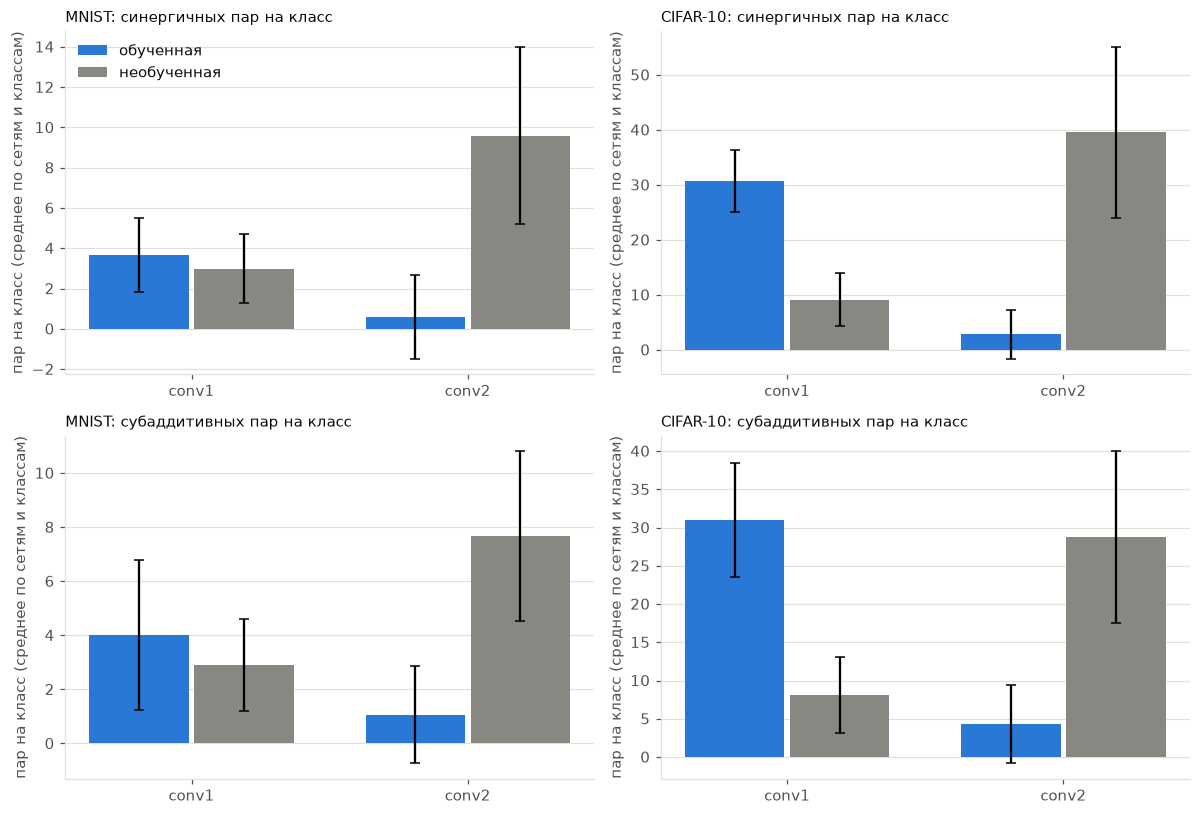

In [5]:
pair_agg = PAIRS.groupby(['dataset', 'net_type', 'layer']).agg(
    synergy_mean=('n_syn', 'mean'), synergy_std=('n_syn', 'std'),
    subadd_mean=('n_sub', 'mean'), subadd_std=('n_sub', 'std'),
).reset_index()
x2 = np.arange(len(LAYERS_PAIR))
fig, axes = plt.subplots(2, len(DATASETS), figsize=(5.5 * len(DATASETS), 7.5), squeeze=False)
for j, ds in enumerate(DATASETS):
    for row, (col_mean, col_std, title) in enumerate([
        ('synergy_mean', 'synergy_std', 'синергичных пар на класс'),
        ('subadd_mean', 'subadd_std', 'субаддитивных пар на класс'),
    ]):
        ax = axes[row, j]
        for i, nt in enumerate(NET_TYPES):
            sub = pair_agg[(pair_agg['dataset'] == ds) & (pair_agg['net_type'] == nt)].set_index('layer').reindex(LAYERS_PAIR)
            ax.bar(x2 + (i - 0.5) * 0.38, sub[col_mean], 0.36, yerr=sub[col_std].fillna(0), capsize=3, color=COL_TYPE[nt], label=nt)
        ax.set_xticks(x2); ax.set_xticklabels(LAYERS_PAIR)
        style(ax, f'{ds}: {title}', yl='пар на класс (среднее по сетям и классам)')
axes[0, 0].legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.show()

### 3.2 Какой тип неаддитивности преобладает: синергия или субаддитивность?

Синергия (S > 0) и субаддитивность (S < 0) - это не два варианта одного и того же "взаимодействия", а разные по
смыслу находки: синергия - узлы дополняют друг друга (по отдельности почти не важны, вместе - важны), субаддитивность -
узлы дублируют друг друга (эффект пары меньше суммы, потому что они частично делают одно и то же, избыточность). Ниже
для каждого типа сети - две палки рядом: сколько синергичных и сколько субаддитивных пар нашлось в слое. Таблица под
графиком даёт то же самое в виде одного числа на сеть - доли синергии среди всех неаддитивных пар.

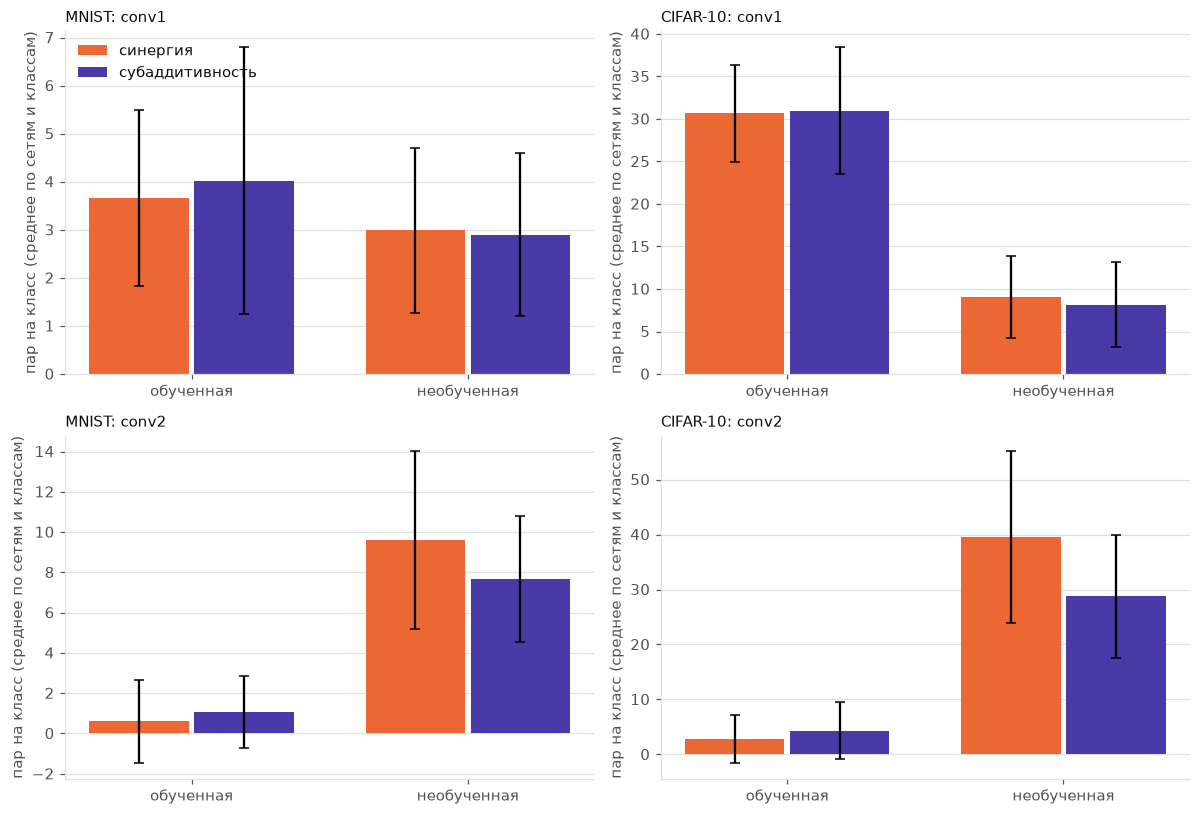

Показатель ниже - доля синергичных пар среди всех неаддитивных (синергия + субаддитивность), посчитана отдельно для каждой сети (по сумме за все 10 классов), затем усреднена по сетям одного типа:


доля синергии: среднее  \
датасет  тип сети    слой                            
CIFAR-10 необученная conv1                   0.530   
                     conv2                   0.580   
         обученная   conv1                   0.499   
                     conv2                   0.389   
MNIST    необученная conv1                   0.514   
                     conv2                   0.555   
         обученная   conv1                   0.487   
                     conv2                   0.369   

                            доля синергии: разброс (std)  доля синергии: мин  \
датасет  тип сети    слой                                                      
CIFAR-10 необученная conv1                         0.032               0.495   
                     conv2                         0.015               0.564   
         обученная   conv1                         0.016               0.472   
                     conv2                         0.093               0.259   
MNIST    необученная conv1                         0.084               0.390   
                     conv2                         0.052               0.471   
         обученная   conv1                         0.057               0.415   
                     conv2                         0.076               0.286   

                            доля синергии: макс  
датасет  тип сети    слой                        
CIFAR-10 необученная conv1                0.571  
                     conv2                0.600  
         обученная   conv1                0.510  
                     conv2                0.506  
MNIST    необученная conv1                0.632  
                     conv2                0.615  
         обученная   conv1                0.568  
                     conv2                0.462

In [6]:
fig, axes = plt.subplots(2, len(DATASETS), figsize=(5.5 * len(DATASETS), 7.5), squeeze=False)
PAIR_COL = {'синергия': '#eb6834', 'субаддитивность': '#4a3aa7'}
xn = np.arange(len(NET_TYPES))
for j, ds in enumerate(DATASETS):
    for row, layer in enumerate(LAYERS_PAIR):
        ax = axes[row, j]
        sub = pair_agg[(pair_agg['dataset'] == ds) & (pair_agg['layer'] == layer)].set_index('net_type').reindex(NET_TYPES)
        ax.bar(xn - 0.19, sub['synergy_mean'], 0.36, yerr=sub['synergy_std'].fillna(0), capsize=3, color=PAIR_COL['синергия'], label='синергия')
        ax.bar(xn + 0.19, sub['subadd_mean'], 0.36, yerr=sub['subadd_std'].fillna(0), capsize=3, color=PAIR_COL['субаддитивность'], label='субаддитивность')
        ax.set_xticks(xn); ax.set_xticklabels(NET_TYPES)
        style(ax, f'{ds}: {layer}', yl='пар на класс (среднее по сетям и классам)')
axes[0, 0].legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.show()

share_rows = PAIRS.groupby(['dataset', 'net_type', 'layer', 'seed'])[['n_syn', 'n_sub']].sum().reset_index()
share_rows['synergy_share'] = share_rows['n_syn'] / (share_rows['n_syn'] + share_rows['n_sub'])
print('Показатель ниже - доля синергичных пар среди всех неаддитивных (синергия + субаддитивность), посчитана отдельно '
      'для каждой сети (по сумме за все 10 классов), затем усреднена по сетям одного типа:')
tbl = share_rows.groupby(['dataset', 'net_type', 'layer'])['synergy_share'].agg(['mean', 'std', 'min', 'max']).round(3)
tbl.columns = ['доля синергии: среднее', 'доля синергии: разброс (std)', 'доля синергии: мин', 'доля синергии: макс']
display(tbl.rename_axis(index={'dataset': 'датасет', 'net_type': 'тип сети', 'layer': 'слой'}))

## 4. Интерпретация

**Разворот по слоям воспроизвёлся и усилился.** Раздел 6.7 `experiment_common_task.ipynb` на 2-3 случайных сетях
увидел разнонаправленный эффект: в conv1 неаддитивных пар больше у обученной сети, в conv2 - у необученной. На
`N_UNTRAINED` = 8 необученных сетях (вместо 2-3) этот разворот не просто воспроизводится - он синхронно повторяется
на двух независимых датасетах:

| слой  | MNIST: обученная | MNIST: необученная | CIFAR-10: обученная | CIFAR-10: необученная |
|-------|------------------:|--------------------:|----------------------:|------------------------:|
| conv1 | **0.512** | 0.392 | **0.514** | 0.144 |
| conv2 | 0.037 | **0.384** | 0.014 | **0.138** |

(доля неаддитивных пар = (синергичных + субаддитивных) / всех протестированных пар слоя, усреднено по классам и сетям)

В conv1 обученная сеть стабильно даёт больше неаддитивных пар, чем необученная. В conv2 - ровно наоборот: необученная
сеть даёт **в 10 раз больше** неаддитивных пар, чем обученная, и на MNIST, и на CIFAR-10. При этом accuracy
необученных сетей - 9.2%/9.5%, то есть уровень угадывания: метод находит в conv2 "значимое" взаимодействие чаще
именно там, где сеть объективно ничего не умеет.

**Почему так может получаться.** Правдоподобная причина - насыщение одиночного критерия. В обученной сети на conv2
почти все узлы и так уже признаны важными поодиночке (это отдельно показано в `experiment_common_task.ipynb`, раздел
6.1, "ограничение 1": если доля критичных узлов близка к 1, критерий ничего не отсеивает). Когда почти всё уже
объявлено важным по одному, парному тесту S мало что остаётся "добавить" - отсюда низкая доля неаддитивных пар у
обученной сети в conv2. В необученной сети критичных поодиночке узлов заметно меньше, остаётся больше необъяснённого,
и именно там S чаще находит "значимое" взаимодействие. Если это верно, значимость S в conv2 отчасти отражает не
взаимодействие узлов само по себе, а то, насколько уже исчерпан потолок одиночного критерия - то есть ровно то
ограничение метрики S, о котором говорит раздел 6.7 `experiment_common_task.ipynb`, только теперь видно не только
"есть ли вообще такие пары в необученной сети", а конкретно в каком слое и в какую сторону происходит смещение.

Второе объяснение: conv2 тестируется в разы большим числом пар, чем conv1 (45 против 15
на MNIST, 496 против 120 на CIFAR-10), а поправка Бенджамини-Иекутили становится строже с ростом числа тестов - часть
разницы между слоями (не обязательно между сетями) может объясняться этим, а не архитектурой или обучением.

**Тип пары тоже различается - и не так, как можно было бы ожидать.** В conv1 доля синергии среди неаддитивных пар
у обеих сетей около 50% - тип пары не различает обученную и необученную сеть. В conv2 - устойчивый перекос в разные
стороны: необученная сеть стабильно (разброс между сетями маленький: std 0.015-0.052) даёт больше синергичных пар,
чем субаддитивных (доля синергии 0.555-0.580), а обученная - стабильно наоборот, больше субаддитивных (доля синергии
0.369-0.389), причём разброс между отдельными обученными сетями заметно выше (std 0.076-0.093) - то есть у необученных
сетей этот перекос похож на почти детерминированное свойство архитектуры, а у обученных - на что-то, что каждый прогон
обучения формирует немного по-своему, но направление почти всегда одно и то же (у CIFAR-10 4 из 5 обученных сетей ниже
0.5).

Если бы синергия была "хорошим" сигналом обучения (распределённое, совместное кодирование), а субаддитивность - просто
шумом случайных весов, ожидался бы перекос в обученной сети к синергии. Получилось ровно наоборот. Правдоподобное
прочтение: то, что тест помечает как "синергию" в необученной сети, вероятно - не распределённое кодирование, а
побочный эффект нелинейности (ReLU + max-pool) на нескоррелированных случайных фильтрах, то есть форма теста создаёт
видимость синергии без содержательной причины. А то немногое, что остаётся значимым в обученной сети на conv2 (его и
так мало - см. выше про насыщение), по характеру оказывается скорее избыточностью уже специализировавшихся, частично
перекрывающихся фильтров - правдоподобный, но отдельный от насыщения механизм: насыщение объясняет, почему пар вообще
мало, перекос к субаддитивности - что это за пары, если они всё-таки находятся.

**Итог.** Метрика S (значимая синергия/субаддитивность пары узлов) не является универсальным индикатором того, что
сеть чему-то научилась: её поведение зависит от слоя и, вероятно, от того, насколько уже насыщен одиночный критерий
в этом слое. В conv1 сигнал от обучения виден. В conv2 - нет, и даже разворачивается в противоположную сторону. Это
эмпирическое ограничение, применимое к валидности S в целом, а не только к конкретному правилу прунинга, которое на
ней основано.